# RNN simples com a diferença


- 1 saida - DeltaTheta
- 2 entradas - Pwmd, Pwme 
- 1 camada
- 1 neurônio


In [47]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

Datasets = []
PREDICTORS = ["PwmD", "PwmE"]
TARGET = "Theta"       

for i in range(4):   
    Dataset = pd.read_csv(f"../Dados/Data{i + 1}.csv")
        
    # Ajusta índice pelo tempo
    Dataset.index = (np.arange(0, len(Dataset), 1).astype(float) * 0.07).round(5)    
    Datasets.append(Dataset)

    print(f"++++++++++++++++++++ Dataset {i+1} +++++++++++++++++++++++")
    print(Dataset.head(5))


++++++++++++++++++++ Dataset 1 +++++++++++++++++++++++
        X    Y  Theta    Wd   We  WdRef  WeRef   PwmD   PwmE
0.00  0.0  0.7   0.00  0.00  0.0  -0.00   0.00  -0.00   0.00
0.07  0.0  0.7   0.00  0.00  0.0   3.02   3.02  -0.00   0.00
0.14  0.0  0.7   0.00  0.00  0.0   3.02   3.02  45.32  45.32
0.21  0.0  0.7   0.01  0.36  0.0   3.02   3.02  45.32  45.32
0.28  0.0  0.7   0.01  0.20  0.0   2.99   3.02  57.60  63.38
++++++++++++++++++++ Dataset 2 +++++++++++++++++++++++
        X    Y  Theta    Wd   We  WdRef  WeRef   PwmD   PwmE
0.00  0.0  0.7    0.0  0.00  0.0  -0.00   0.00  -0.00   0.00
0.07  0.0  0.7    0.0  0.00  0.0   3.02   3.02  -0.00   0.00
0.14  0.0  0.7    0.0  0.00  0.0   3.02   3.02  45.32  45.32
0.21  0.0  0.7    0.0  0.03  0.0   3.02   3.02  45.32  45.32
0.28  0.0  0.7    0.0  0.00  0.0   3.02   3.02  63.00  63.44
++++++++++++++++++++ Dataset 3 +++++++++++++++++++++++
        X    Y  Theta   Wd   We  WdRef  WeRef   PwmD   PwmE
0.00  0.0  0.7    0.0  0.0  0.0  -0.00   0.

In [48]:
for  i in range(4):
    Dataset = Datasets[i].copy()
    Dataset["DeltaTheta"] = Dataset[TARGET].shift(-1) - Dataset[TARGET]
    
    Dataset = Dataset.dropna(subset=["DeltaTheta"])
    Datasets[i] = Dataset
    print(f"++++++++++++++++++++ Dataset {i+1} +++++++++++++++++++++++")
    print(Datasets[i].tail(5))


++++++++++++++++++++ Dataset 1 +++++++++++++++++++++++
          X     Y  Theta    Wd    We  WdRef  WeRef    PwmD    PwmE  DeltaTheta
99.05  0.05  0.65  -0.83 -2.76 -3.35  -2.84  -3.05 -103.15 -117.71         0.0
99.12  0.05  0.65  -0.83 -2.79 -3.12  -2.86  -3.06 -104.13 -115.63         0.0
99.19  0.04  0.66  -0.83 -3.29 -3.18  -2.88  -3.06 -104.13 -115.63         0.0
99.26  0.04  0.66  -0.83 -3.26 -3.18  -2.86  -3.05  -96.76 -116.39         0.0
99.33  0.03  0.67  -0.83 -3.09 -3.01  -2.84  -3.05  -96.76 -116.39         0.0
++++++++++++++++++++ Dataset 2 +++++++++++++++++++++++
          X     Y  Theta    Wd    We  WdRef  WeRef    PwmD    PwmE  DeltaTheta
88.62  0.04  0.65  -0.78 -2.73 -2.65  -2.95  -2.66 -108.21 -110.17        0.00
88.69  0.04  0.65  -0.78 -2.54 -2.54  -2.94  -2.65 -108.21 -110.17       -0.01
88.76  0.04  0.65  -0.79 -2.87 -2.59  -2.93  -2.62 -113.11 -112.34       -0.01
88.83  0.03  0.66  -0.80 -3.07 -2.68  -2.92  -2.61 -113.11 -112.34       -0.01
88.90  0.03  0.66  -0

In [49]:
NormDatasets = []
TARGET = ["DeltaTheta"]

SCALER = StandardScaler()
OUT_SCALER = StandardScaler()

TrainDataset = Datasets[0]
TrainDataset[PREDICTORS] = SCALER.fit_transform(TrainDataset[PREDICTORS])
TrainDataset[TARGET] = OUT_SCALER.fit_transform(TrainDataset[TARGET])
NormDatasets.append(TrainDataset)

for i in range(3):
      CurrentTestDataset = Datasets[i + 1]
      CurrentTestDataset[PREDICTORS] = SCALER.transform(CurrentTestDataset[PREDICTORS])
      CurrentTestDataset[TARGET] = OUT_SCALER.transform(CurrentTestDataset[TARGET])
      NormDatasets.append(CurrentTestDataset)
      print(f"++++++++++++++++++++ Dataset Normalizado {i+1} +++++++++++++++++++++++")
      print(NormDatasets[i].head(5))

++++++++++++++++++++ Dataset Normalizado 1 +++++++++++++++++++++++
        X    Y  Theta    Wd   We  WdRef  WeRef      PwmD      PwmE  DeltaTheta
0.00  0.0  0.7   0.00  0.00  0.0  -0.00   0.00  0.463678  0.398857    0.034019
0.07  0.0  0.7   0.00  0.00  0.0   3.02   3.02  0.463678  0.398857    0.034019
0.14  0.0  0.7   0.00  0.00  0.0   3.02   3.02  1.081737  0.886844    0.616022
0.21  0.0  0.7   0.01  0.36  0.0   3.02   3.02  1.081737  0.886844    0.034019
0.28  0.0  0.7   0.01  0.20  0.0   2.99   3.02  1.249208  1.081307    0.034019
++++++++++++++++++++ Dataset Normalizado 2 +++++++++++++++++++++++
        X    Y  Theta    Wd   We  WdRef  WeRef      PwmD      PwmE  DeltaTheta
0.00  0.0  0.7    0.0  0.00  0.0  -0.00   0.00  0.463678  0.398857    0.034019
0.07  0.0  0.7    0.0  0.00  0.0   3.02   3.02  0.463678  0.398857    0.034019
0.14  0.0  0.7    0.0  0.00  0.0   3.02   3.02  1.081737  0.886844    0.034019
0.21  0.0  0.7    0.0  0.03  0.0   3.02   3.02  1.081737  0.886844    0.0340

In [50]:
def CreateSequences(input_data, target_data, timesteps):
    X_seq, Y_seq = [], []
    
    for i in range(timesteps, len(input_data)):
        X_seq.append(input_data.iloc[i-timesteps:i].values)
        Y_seq.append(target_data.iloc[i])
    return np.array(X_seq), np.array(Y_seq)

In [51]:
x_train = TrainDataset[PREDICTORS]
y_train = TrainDataset[TARGET]

TIME_STEPS = 5

x_train, y_train = CreateSequences(x_train, y_train, TIME_STEPS)

x_val = (NormDatasets[1])[PREDICTORS]
y_val = (NormDatasets[1])[TARGET]

x_val, y_val = CreateSequences(x_val, y_val, TIME_STEPS)


print(f"Dimensão da entrada: {np.shape(x_train)}")
print(f"Dimensão da saida: {np.shape(y_train)}")

Dimensão da entrada: (1415, 5, 2)
Dimensão da saida: (1415, 1)


In [52]:
import matplotlib.pyplot as plt

def PlotHistory(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training History')
    plt.legend()
    plt.grid(True)
    plt.show()
    
import matplotlib.pyplot as plt
import numpy as np

def PlotOut(ax, title, y_true, y_pred):
    """Plota um conjunto de saídas reais e preditas em um eixo específico."""
    y_true = np.ravel(y_true)
    y_pred = np.ravel(y_pred)
    time = (np.arange(0, len(y_pred), 1).astype(float) * 0.07).round(5)

    ax.plot(time, y_true, marker="o", linestyle="None", label="Amostras Reais", color="gray")
    ax.plot(time, y_pred, marker="x", linestyle="None", label="Valores Preditos", color="blue")

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Tempo (s)", fontsize=11)
    ax.set_ylabel("Theta", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.6)
    
    

In [56]:
from sklearn.metrics import mean_squared_error, r2_score

TITLES = ["Treinamento", "Validação", "Test 1", "Test 2"]

def EvalModel(model):
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    axs = axs.ravel()  # transforma matriz de eixos em vetor 1D
    
    for i, dataset in enumerate(NormDatasets):
        x = dataset[PREDICTORS]
        y = dataset[TARGET]
        x, y = CreateSequences(x, y, TIME_STEPS)

        y_pred_diff = OUT_SCALER.inverse_transform(model.predict(x))
        y_diff = OUT_SCALER.inverse_transform(y)        
        
        # valor inicial de theta no dataset original (não normalizado)
        theta0 = Datasets[i]["Theta"].iloc[0]  
        
        # reconstrução: soma cumulativa
        y_real = theta0 + np.cumsum(y_diff, axis=0)
        y_pred = theta0 + np.cumsum(y_pred_diff, axis=0)
        
        # métricas no espaço de θ
        R2 = r2_score(y_real, y_pred)
        MSE = mean_squared_error(y_real, y_pred)
        print(f"R²_{TITLES[i]} = {R2}")
        print(f"MSE_{TITLES[i]} = {MSE}")
        
        # plota saída
        PlotOut(axs[i], TITLES[i], y_real, y_pred)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f"./fig.pdf", format="pdf", dpi=600)


In [57]:
from tensorflow import keras
from keras.callbacks import EarlyStopping
import ast

INPUT_SIZE = len(PREDICTORS)  
OUTPUT_SIZE = len(TARGET) 

model = keras.models.Sequential([
    keras.layers.Input(shape=(TIME_STEPS, INPUT_SIZE)),
    keras.layers.SimpleRNN(4, activation="tanh"),
    keras.layers.Dense(OUTPUT_SIZE, activation="linear"),  
])
Wf = "[[[-0.3021000027656555, -0.26080000400543213, -0.2386000007390976, -0.07620000094175339], [0.030400000512599945, -0.28679999709129333, 0.24860000610351562, 0.2888999879360199]], [[-0.17479999363422394, 0.5478000044822693, 1.330899953842163, -0.37040001153945923], [0.8528000116348267, -0.06520000100135803, -0.46129998564720154, -0.9347000122070312], [-0.9904999732971191, -0.2696000039577484, -0.41179999709129333, -1.0120999813079834], [-0.6879000067710876, 1.121999979019165, -0.4018999934196472, -0.27889999747276306]], [0.06669999659061432, -0.5989000201225281, 0.1128000020980835, -0.019999999552965164], [[1.1571999788284302], [-0.8894000053405762], [0.6425999999046326], [0.7473999857902527]], [0.11749999970197678]]"
Wf = [np.array(w) for w in ast.literal_eval(Wf)]
model.set_weights(Wf)


Configures the model for training.

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
R²_Treinamento = 0.7718478512248275
MSE_Treinamento = 0.07509798258789145
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
R²_Validação = 0.06829829954255162
MSE_Validação = 0.3053199565876232
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
R²_Test 1 = 0.8551185218448568
MSE_Test 1 = 0.0415201669615227
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
R²_Test 2 = 0.8113616873141867
MSE_Test 2 = 0.06388193130521777


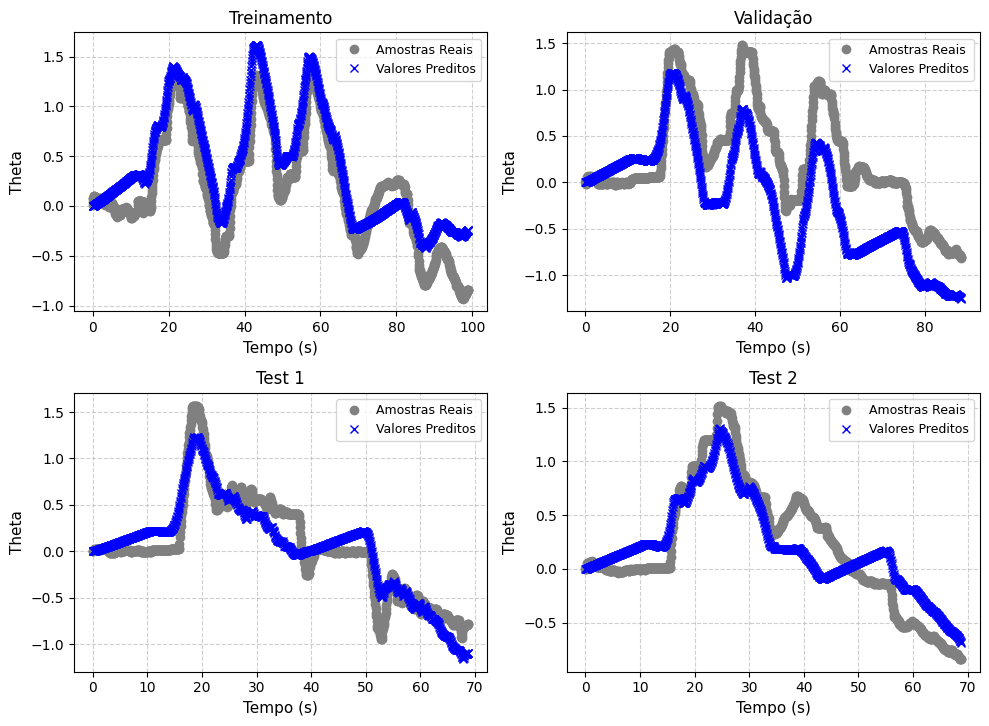

In [58]:
EvalModel(model)